# Customer Churn Data Analysis and Preprocessing
This notebook loads, cleans, visualizes, and merges client and pricing data to analyze churn. It follows functional programming principles, avoids global states, and is executed step-by-step for an interactive EDA experience.

In [1]:
# ==========================================
# 1. IMPORTS & CONFIGURATION
# ==========================================
import os
import logging
import warnings
from pathlib import Path
from typing import List, Tuple

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Suppress warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Configure Pandas display options and Seaborn visual themes
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style="whitegrid", color_codes=True)

# Configure logging instead of print for production-readiness
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Environment variable for Data Directory (Defaulting to '../data')
DATA_DIR = Path(os.getenv('DATA_DIR', str(Path.cwd().parent / 'data')))

## 2. Data Loading & Profiling
Define the data loading function and execute it immediately to inspect the raw datasets.

In [2]:
def load_datasets(data_path: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Loads client and price datasets from the specified directory.

    Args:
        data_path (Path): The directory path containing the CSV files.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: A tuple containing (client_df, price_df).
    """
    client_file = data_path / 'client_data.csv'
    price_file = data_path / 'price_data.csv'

    try:
        logger.info(f"Loading data from {data_path}")
        client_data = pd.read_csv(client_file)
        price_data = pd.read_csv(price_file)
        
        logger.info(f"Client data loaded. Shape: {client_data.shape}")
        logger.info(f"Price data loaded. Shape: {price_data.shape}")
        
        return client_data, price_data
        
    except FileNotFoundError as e:
        logger.error(f"Failed to load data files: {e}")
        raise

In [3]:
# Execution
client_df, price_df = load_datasets(DATA_DIR)

logger.info("--- Client Data Preview ---")
display(client_df.head(3))
display(client_df.info())

logger.info("--- Price Data Preview ---")
display(price_df.head(3))
display(price_df.info())

2026-05-01 15:09:49,243 - INFO - Loading data from /Users/selim/venv/job_simulation/data
2026-05-01 15:09:49,389 - INFO - Client data loaded. Shape: (14606, 26)
2026-05-01 15:09:49,389 - INFO - Price data loaded. Shape: (193002, 8)
2026-05-01 15:09:49,389 - INFO - --- Client Data Preview ---


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0000,0,0.0000,1.7800,0.1145,0.0981,40.6067,t,0.0000,25.4400,25.4400,2,678.9900,3,lxidpiddsbxsbosboudacockeimpuepw,43.6480,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.9500,0,0.0000,16.2700,0.1457,0.0000,44.3114,f,0.0000,16.3800,16.3800,1,18.8900,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.9600,0,0.0000,38.7200,0.1658,0.0879,44.3114,f,0.0000,28.6000,28.6000,1,6.6000,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8560,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

None

2026-05-01 15:09:49,409 - INFO - --- Price Data Preview ---


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


None

## 3. Preprocessing & Feature Engineering
Format datetime columns and safely map categorical boolean columns like 'has_gas'.

In [4]:
def preprocess_client_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocesses the client data by converting datetime columns and mapping categoricals.

    Args:
        df (pd.DataFrame): Raw client dataframe.

    Returns:
        pd.DataFrame: Preprocessed client dataframe.
    """
    processed_df = df.copy()
    date_cols =['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
    
    try:
        processed_df[date_cols] = processed_df[date_cols].apply(pd.to_datetime, errors='coerce')
        
        if 'has_gas' in processed_df.columns:
            processed_df['has_gas'] = processed_df['has_gas'].map({'t': 1, 'f': 0}).fillna(0).astype(int)
            
        return processed_df
    except Exception as e:
        logger.error(f"Error during client data preprocessing: {e}")
        raise

def preprocess_price_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocesses the price data by converting the reference date column.
    """
    processed_df = df.copy()
    try:
        processed_df['price_date'] = pd.to_datetime(processed_df['price_date'], errors='coerce')
        return processed_df
    except Exception as e:
        logger.error(f"Error during price data preprocessing: {e}")
        raise

In [5]:
# Execution
client_df = preprocess_client_data(client_df)
price_df = preprocess_price_data(price_df)
logger.info("Data preprocessing completed. Datetimes converted and categoricals mapped.")

2026-05-01 15:09:49,459 - INFO - Data preprocessing completed. Datetimes converted and categoricals mapped.


## 4. Aggregation & Merging: Overall Churn Distribution
Visualize the general proportion of churned vs retained customers.

In [6]:
def plot_churn_distribution(df: pd.DataFrame) -> None:
    """
    Plots the overall churn distribution proportion.

    Args:
        df (pd.DataFrame): The dataset containing the 'churn' column.
    """
    try:
        fig, ax = plt.subplots(figsize=(5, 5))
        churn_pct = df['churn'].value_counts(normalize=True).to_frame('proportion').T
        
        display(churn_pct)
        
        churn_pct.plot.bar(stacked=True, ax=ax, legend=False, width=0.5)

        for container in ax.containers:
            ax.bar_label(
                container, 
                fmt=lambda x: f'{x * 100:.2f}%' if x > 0 else '', 
                label_type='center', 
                color='white', 
                fontweight='bold', 
                fontsize=12
            )

        ax.legend(['Retention', 'Churn'], loc='upper right', bbox_to_anchor=(1.35, 1))
        ax.set_title("Churn Distribution", pad=15, fontweight='bold')
        ax.set_xticks([]) 
        
        plt.tight_layout()
        plt.show()
    except KeyError:
        logger.error("Column 'churn' not found in the dataset.")
        raise

churn,0,1
proportion,0.9028,0.0972


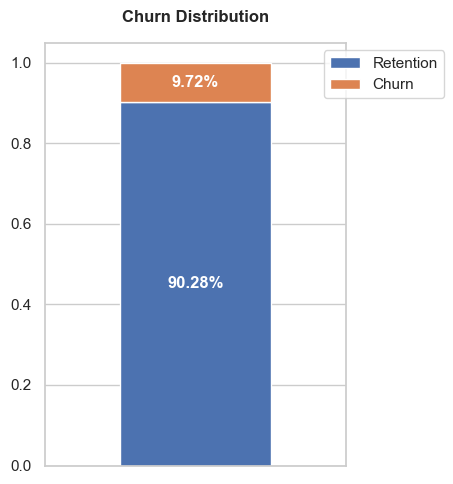

In [7]:
# Execution
plot_churn_distribution(client_df)

## 5. Consumption Analysis (Histograms & Boxplots)
Define utility functions to visualize numeric distributions by churn, and run them for consumption columns.

In [8]:
def plot_histograms(df: pd.DataFrame, cols: List[str]) -> None:
    """Plots stacked histograms for a list of columns based on churn status."""
    try:
        fig, axes = plt.subplots(nrows=len(cols), figsize=(15, 5 * len(cols)))
        if len(cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, cols):
            retention = df[df['churn'] == 0][col].dropna()
            churn = df[df['churn'] == 1][col].dropna()

            ax.hist([retention, churn], bins=50, stacked=True, label=['Retention', 'Churn'])
            ax.set_title(f'{col} Distribution by Churn')
            ax.set_xlabel(col)
            ax.set_ylabel('Count')
            ax.ticklabel_format(style='plain', axis='x')
            ax.legend()

        plt.tight_layout()
        plt.show()
    except Exception as e:
        logger.error(f"Error plotting histograms: {e}")
        raise

def plot_boxplot(df: pd.DataFrame, cols: List[str]) -> None:
    """Plots boxplots for given features against churn to identify outliers."""
    try:
        fig, axes = plt.subplots(nrows=len(cols), figsize=(15, 5 * len(cols)))
        if len(cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, cols):
            sns.boxplot(data=df, x=col, ax=ax)
            ax.set_title(f'{col} Distribution')
            ax.set_ylabel(col)
            ax.set_xlabel('')
            ax.ticklabel_format(style='plain', axis='x')

        plt.tight_layout()
        plt.show()
    except Exception as e:
        logger.error(f"Error plotting boxplots: {e}")
        raise



2026-05-01 15:09:49,577 - INFO - Plotting histograms for consumption variables


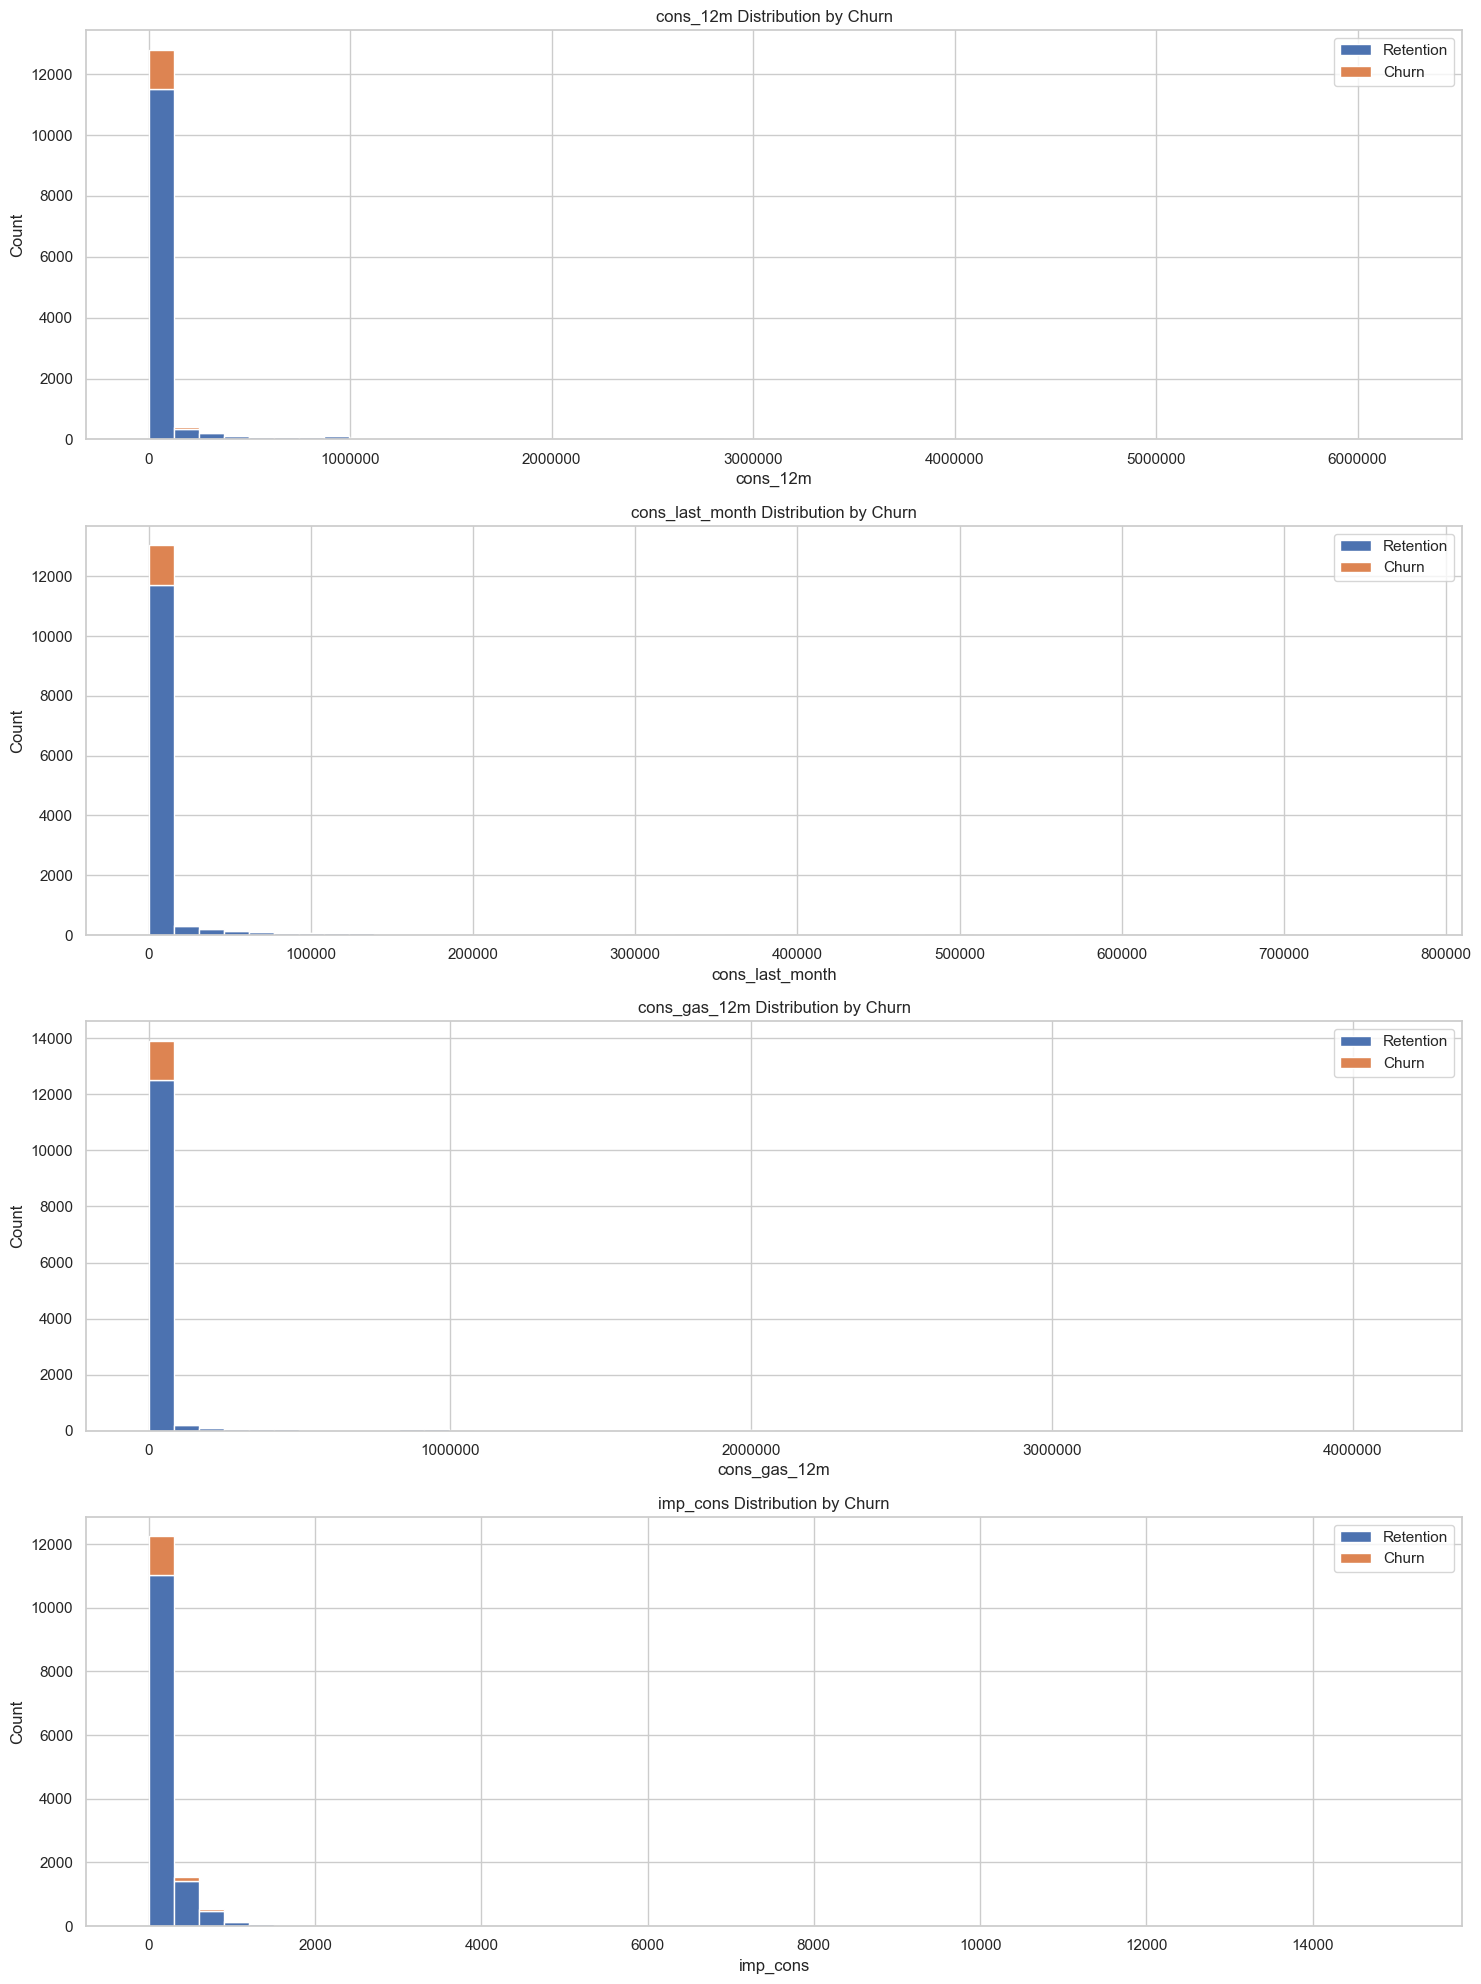

In [9]:
# Execution for consumption features
cons_cols =['cons_12m', 'cons_last_month', 'cons_gas_12m', 'imp_cons']

logger.info("Plotting histograms for consumption variables")
plot_histograms(client_df, cons_cols)

2026-05-01 15:09:49,977 - INFO - Plotting boxplots for consumption variables


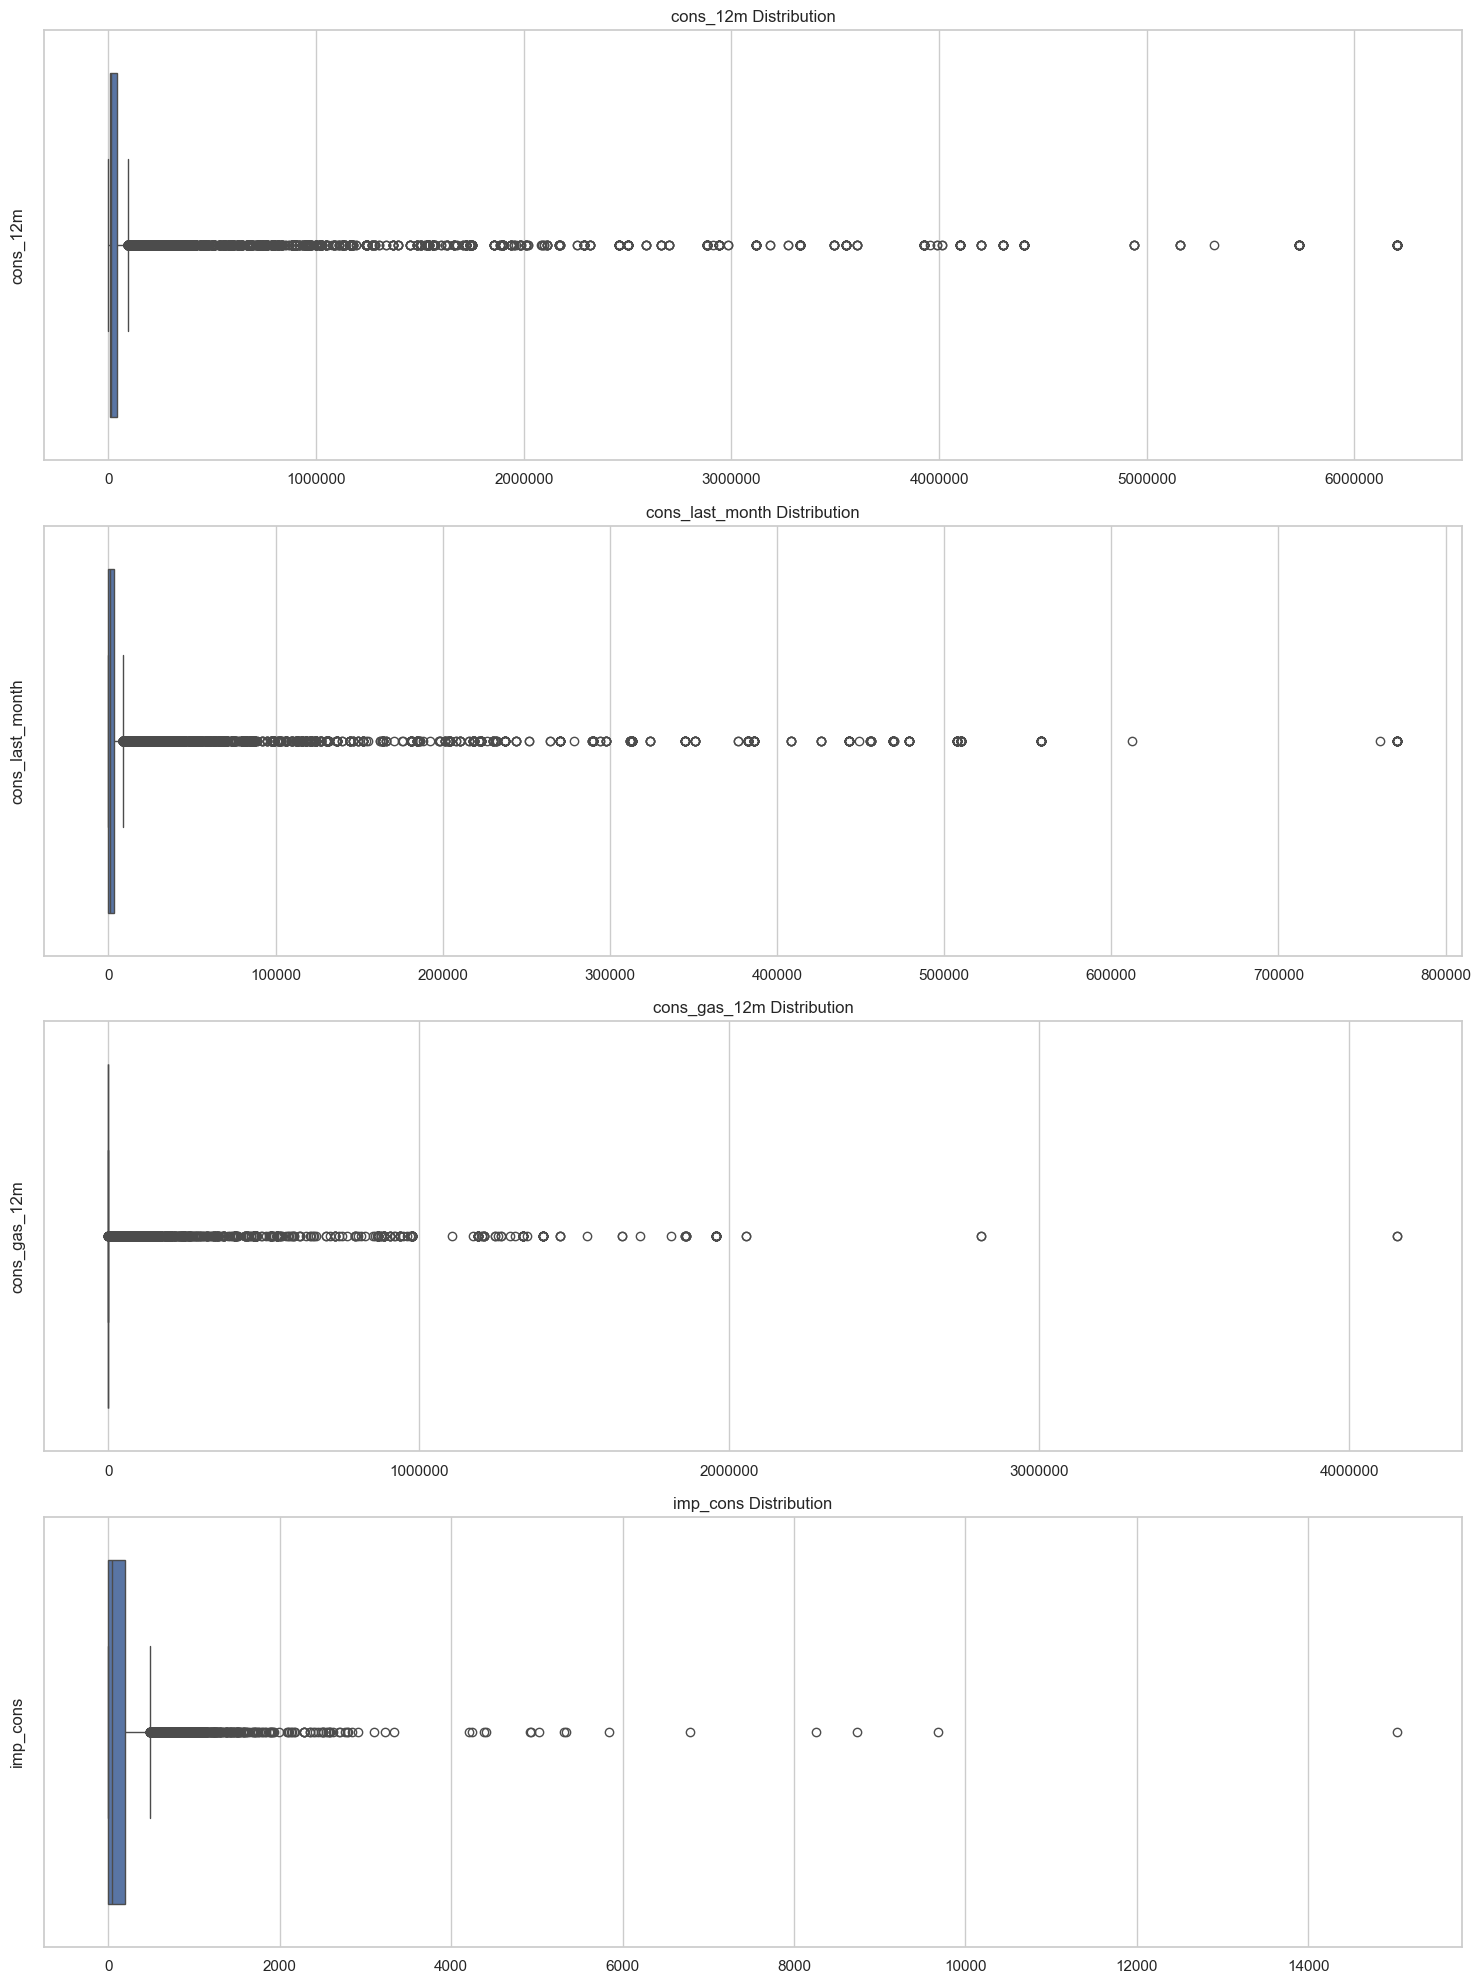

In [10]:
# Execution for consumption features
cons_cols =['cons_12m', 'cons_last_month', 'cons_gas_12m', 'imp_cons']

logger.info("Plotting boxplots for consumption variables")
plot_boxplot(client_df, cons_cols)

## 6. Correlation Heatmap
Examine the correlation between consumption variables and margin variables.

In [11]:
def plot_correlation_heatmap(df: pd.DataFrame, cols_1: List[str], cols_2: List[str]) -> None:
    """Plots a specific block of the correlation matrix between two sets of columns."""
    try:
        corr = df[cols_1 + cols_2].corr()
        heatmap_data = corr.loc[cols_1, cols_2]

        plt.figure(figsize=(8, 6))
        sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("3x3 Feature Correlation Heatmap")
        plt.show()
    except KeyError as e:
        logger.error(f"Columns missing for correlation heatmap: {e}")
        raise

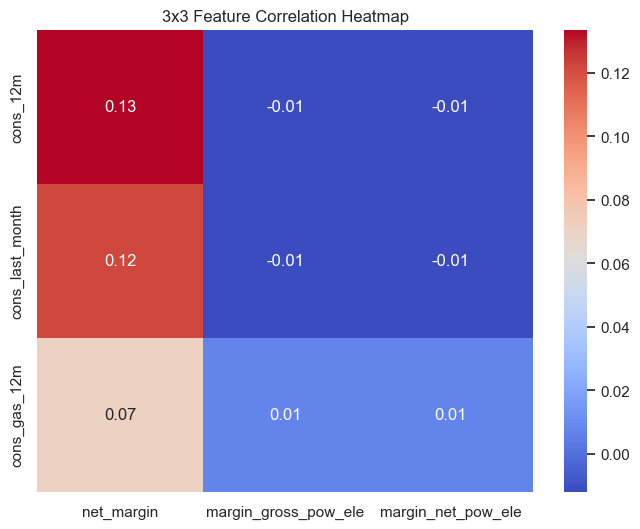

In [12]:
# Execution
cols_1 =['cons_12m', 'cons_last_month', 'cons_gas_12m']
cols_2 =['net_margin', 'margin_gross_pow_ele', 'margin_net_pow_ele']

plot_correlation_heatmap(client_df, cols_1, cols_2)

## 7. Categorical Variables against Churn
Visualize the proportions of churn across different categorical features.

In [13]:
def plot_stacked_bars(df: pd.DataFrame, cols: List[str]) -> None:
    """Plots normalized stacked bar charts to compare categorical proportions by churn."""
    try:
        fig, axes = plt.subplots(nrows=len(cols), figsize=(15, 5 * len(cols)))
        if len(cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, cols):
            grouped = pd.crosstab(df[col], df['churn'], normalize='index')
            grouped = grouped.loc[grouped[1].sort_values(ascending=False).index]

            grouped.plot(kind='bar', stacked=True, ax=ax, width=0.7)

            for i, category in enumerate(grouped.index):
                bottom = 0
                for churn_val in grouped.columns:
                    value = grouped.loc[category, churn_val]
                    if value > 0.05:
                        ax.text(
                            i, bottom + value / 2, f'{value * 100:.1f}%',
                            ha='center', va='center', color='white', 
                            fontsize=10, fontweight='bold'
                        )
                    bottom += value

            ax.set_title(f'Churn Distribution by {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Proportion')
            ax.legend(title='Churn', loc='upper right')
            ax.tick_params(axis='x', labelrotation=45 if any(len(str(x)) > 10 for x in grouped.index) else 0)

        plt.tight_layout()
        plt.show()
    except Exception as e:
        logger.error(f"Error plotting stacked bars: {e}")
        raise

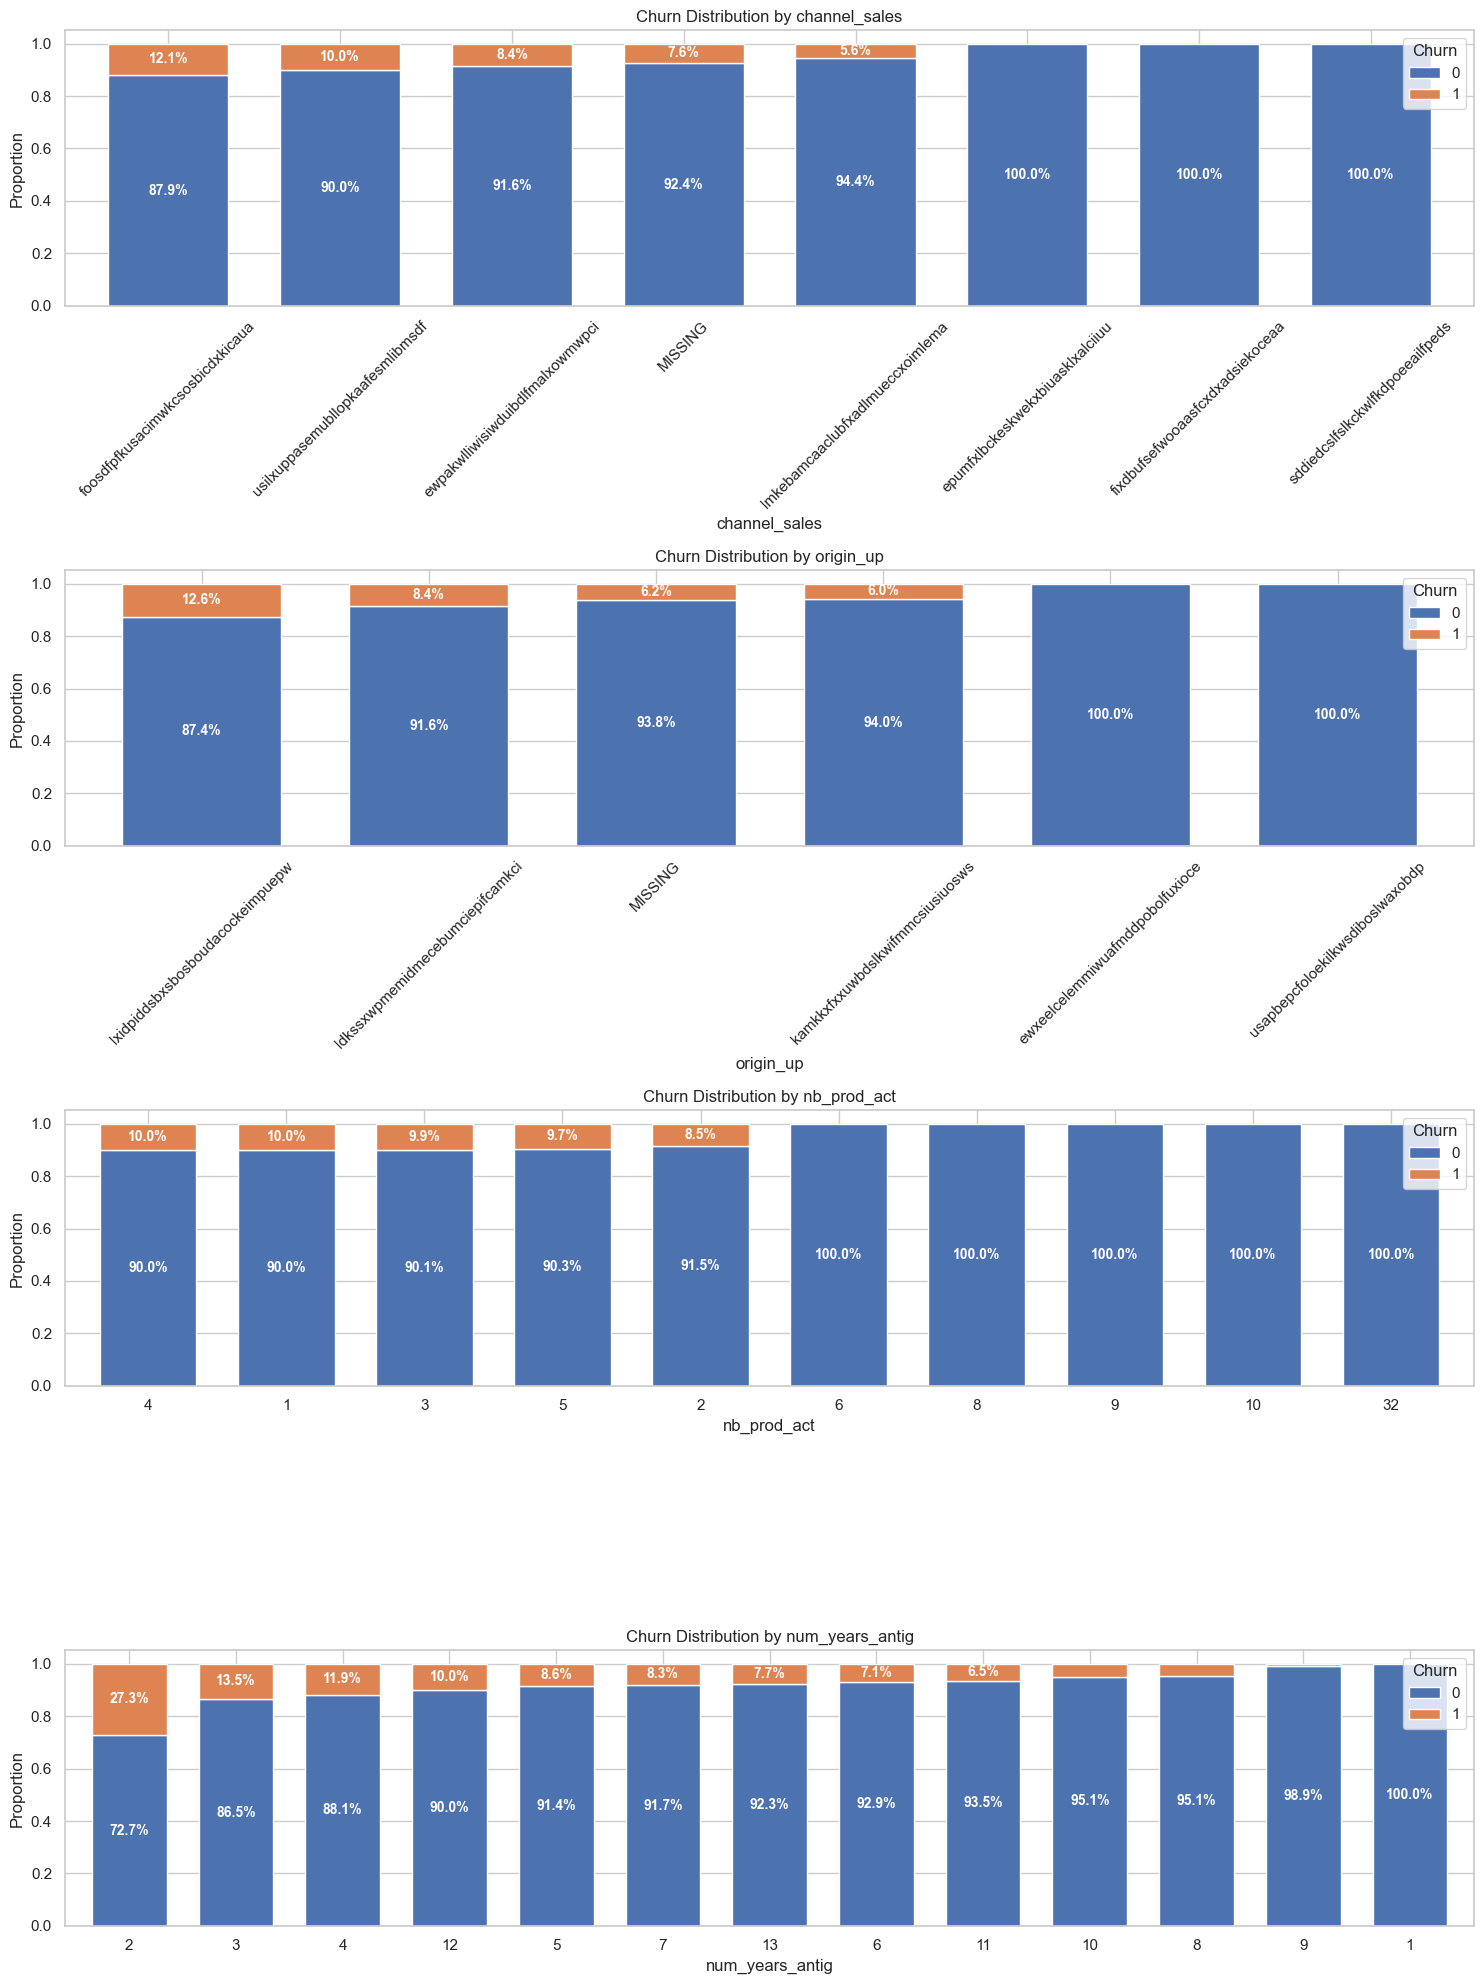

In [14]:
# Execution
cat_cols =['channel_sales', 'origin_up', 'nb_prod_act', 'num_years_antig']
plot_stacked_bars(client_df, cat_cols)

2026-05-01 15:09:50,607 - INFO - Plotting churn distribution by 'has_gas' status


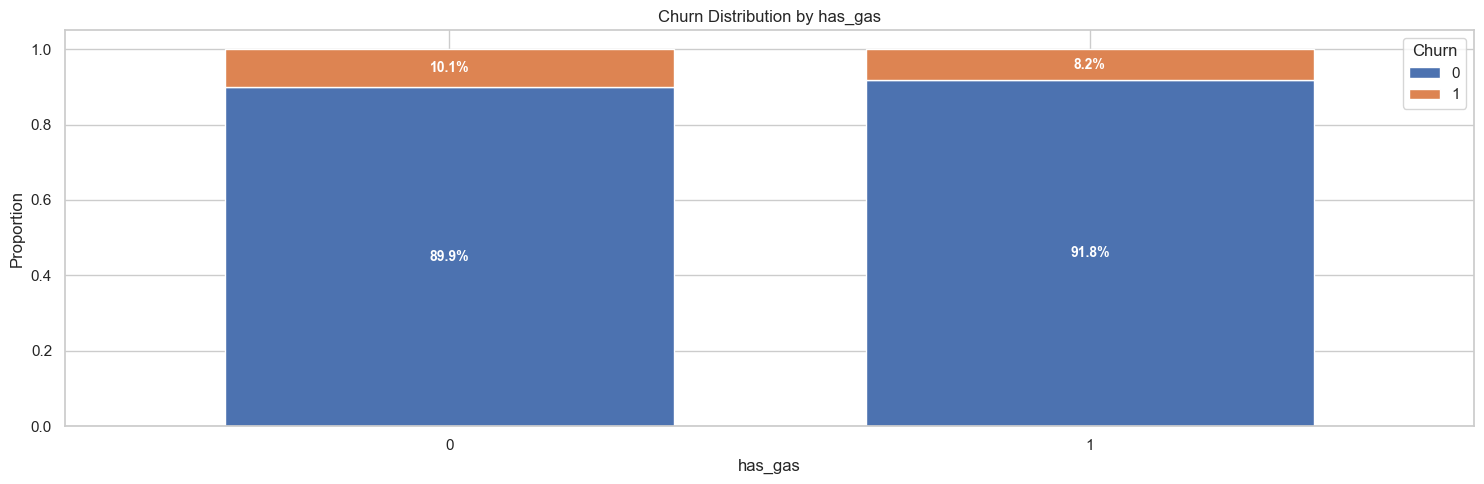

In [15]:
# Execution
logger.info("Plotting churn distribution by 'has_gas' status")
plot_stacked_bars(client_df, ['has_gas'])

## 8. Forecast and Margin Analysis
Analyze forecasted variables, margins, and subscribed power.

2026-05-01 15:09:50,670 - INFO - Plotting histograms for forecasted variables


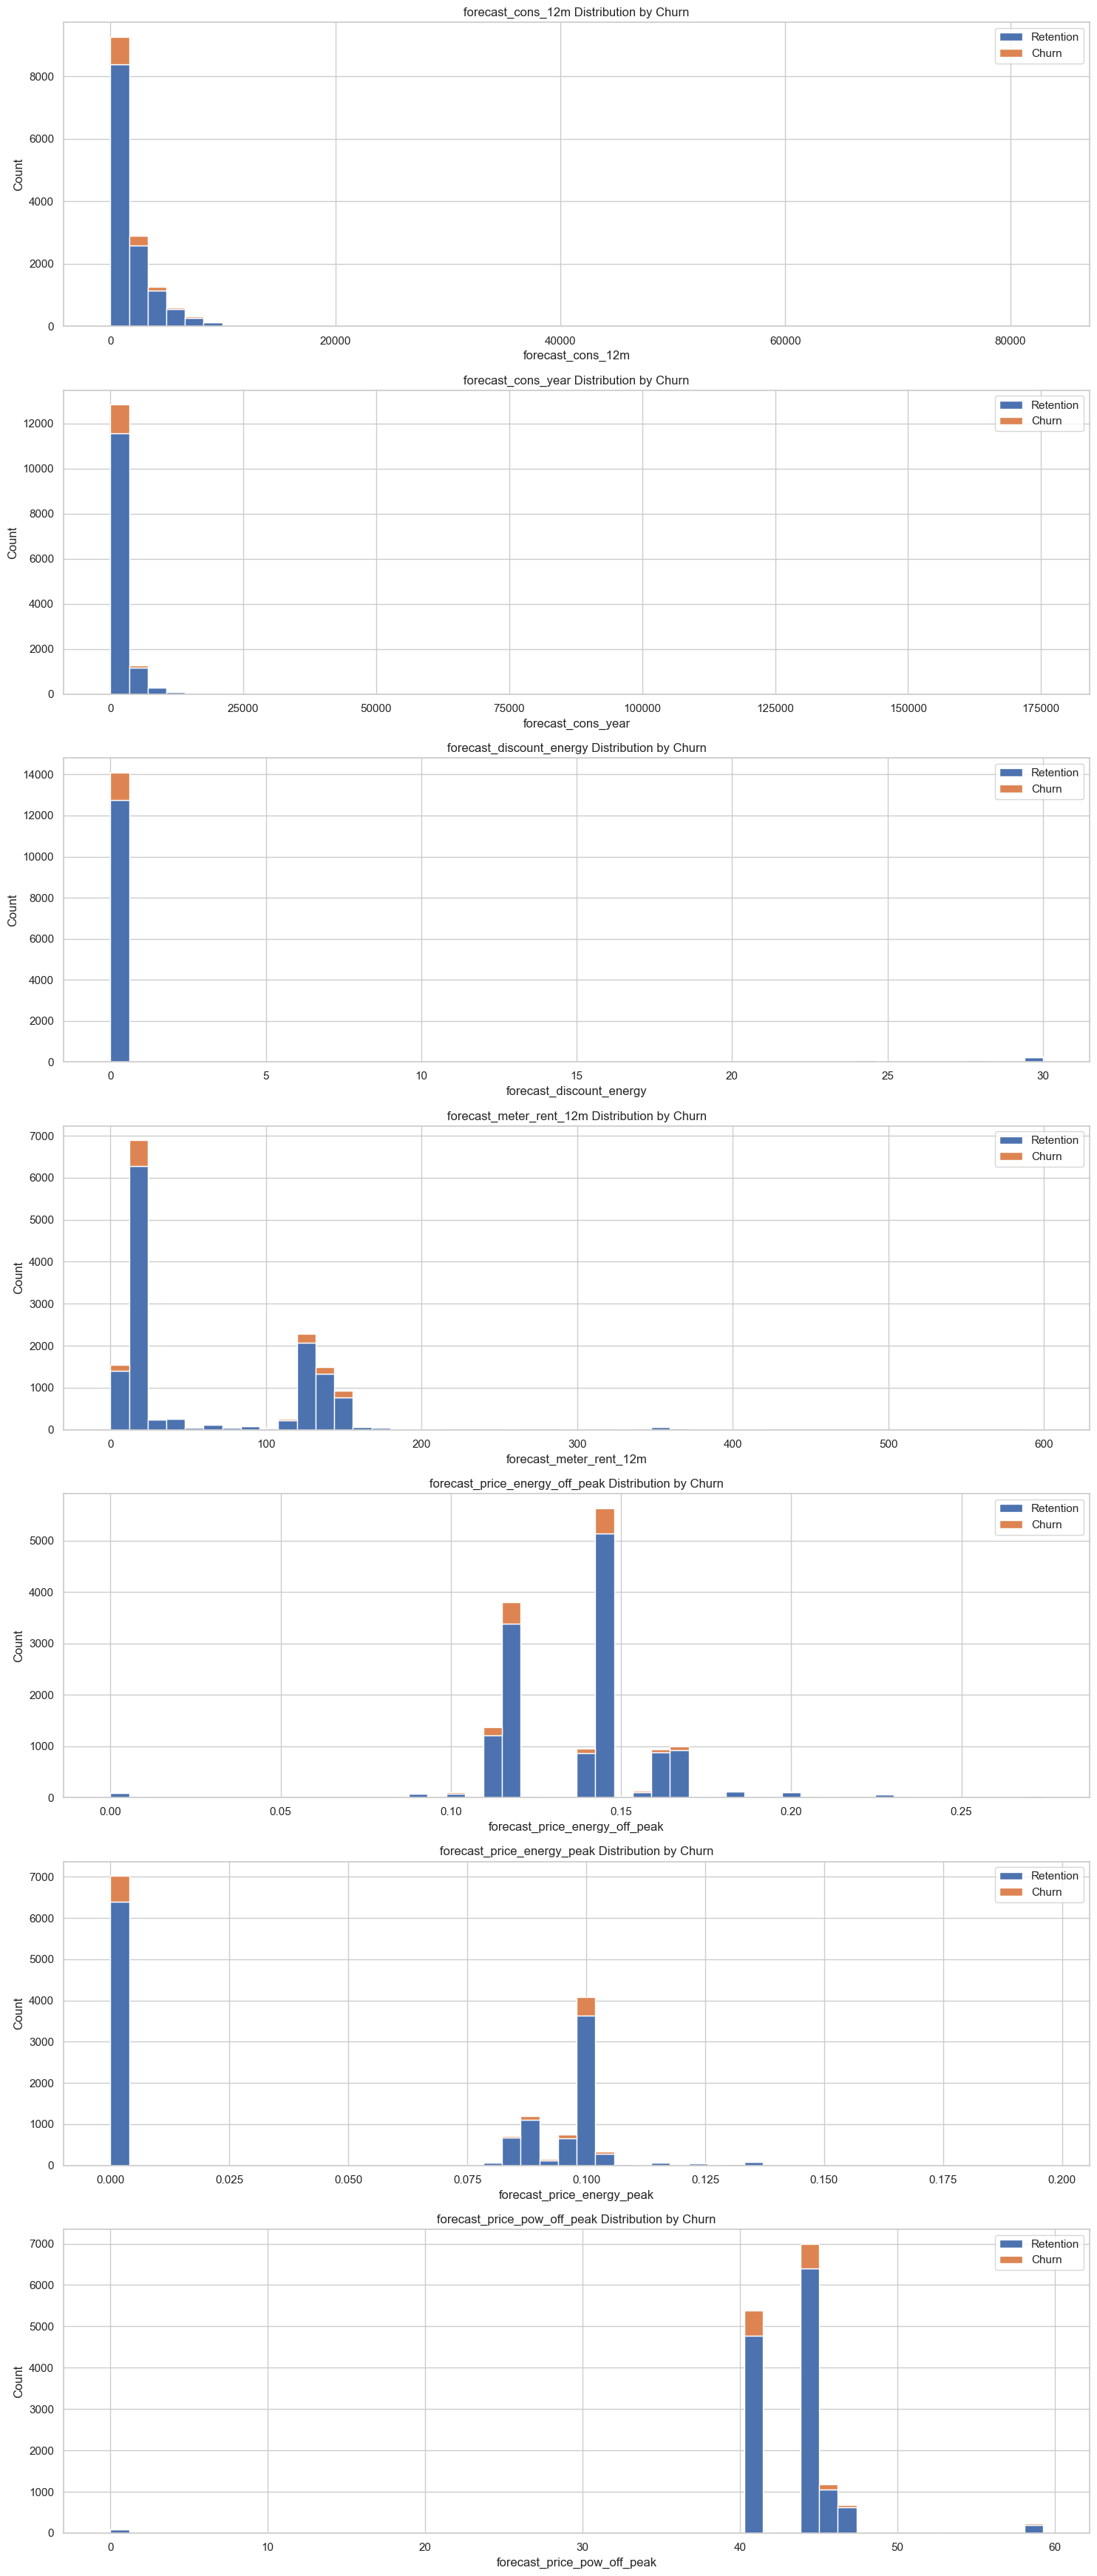

In [16]:
# Execution for forecast variables
forecast_cols =[
    'forecast_cons_12m', 
    'forecast_cons_year', 
    'forecast_discount_energy',
    'forecast_meter_rent_12m', 
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak', 
    'forecast_price_pow_off_peak'
]
logger.info("Plotting histograms for forecasted variables")
plot_histograms(client_df, forecast_cols)

2026-05-01 15:09:51,430 - INFO - Plotting boxplots for margin variables


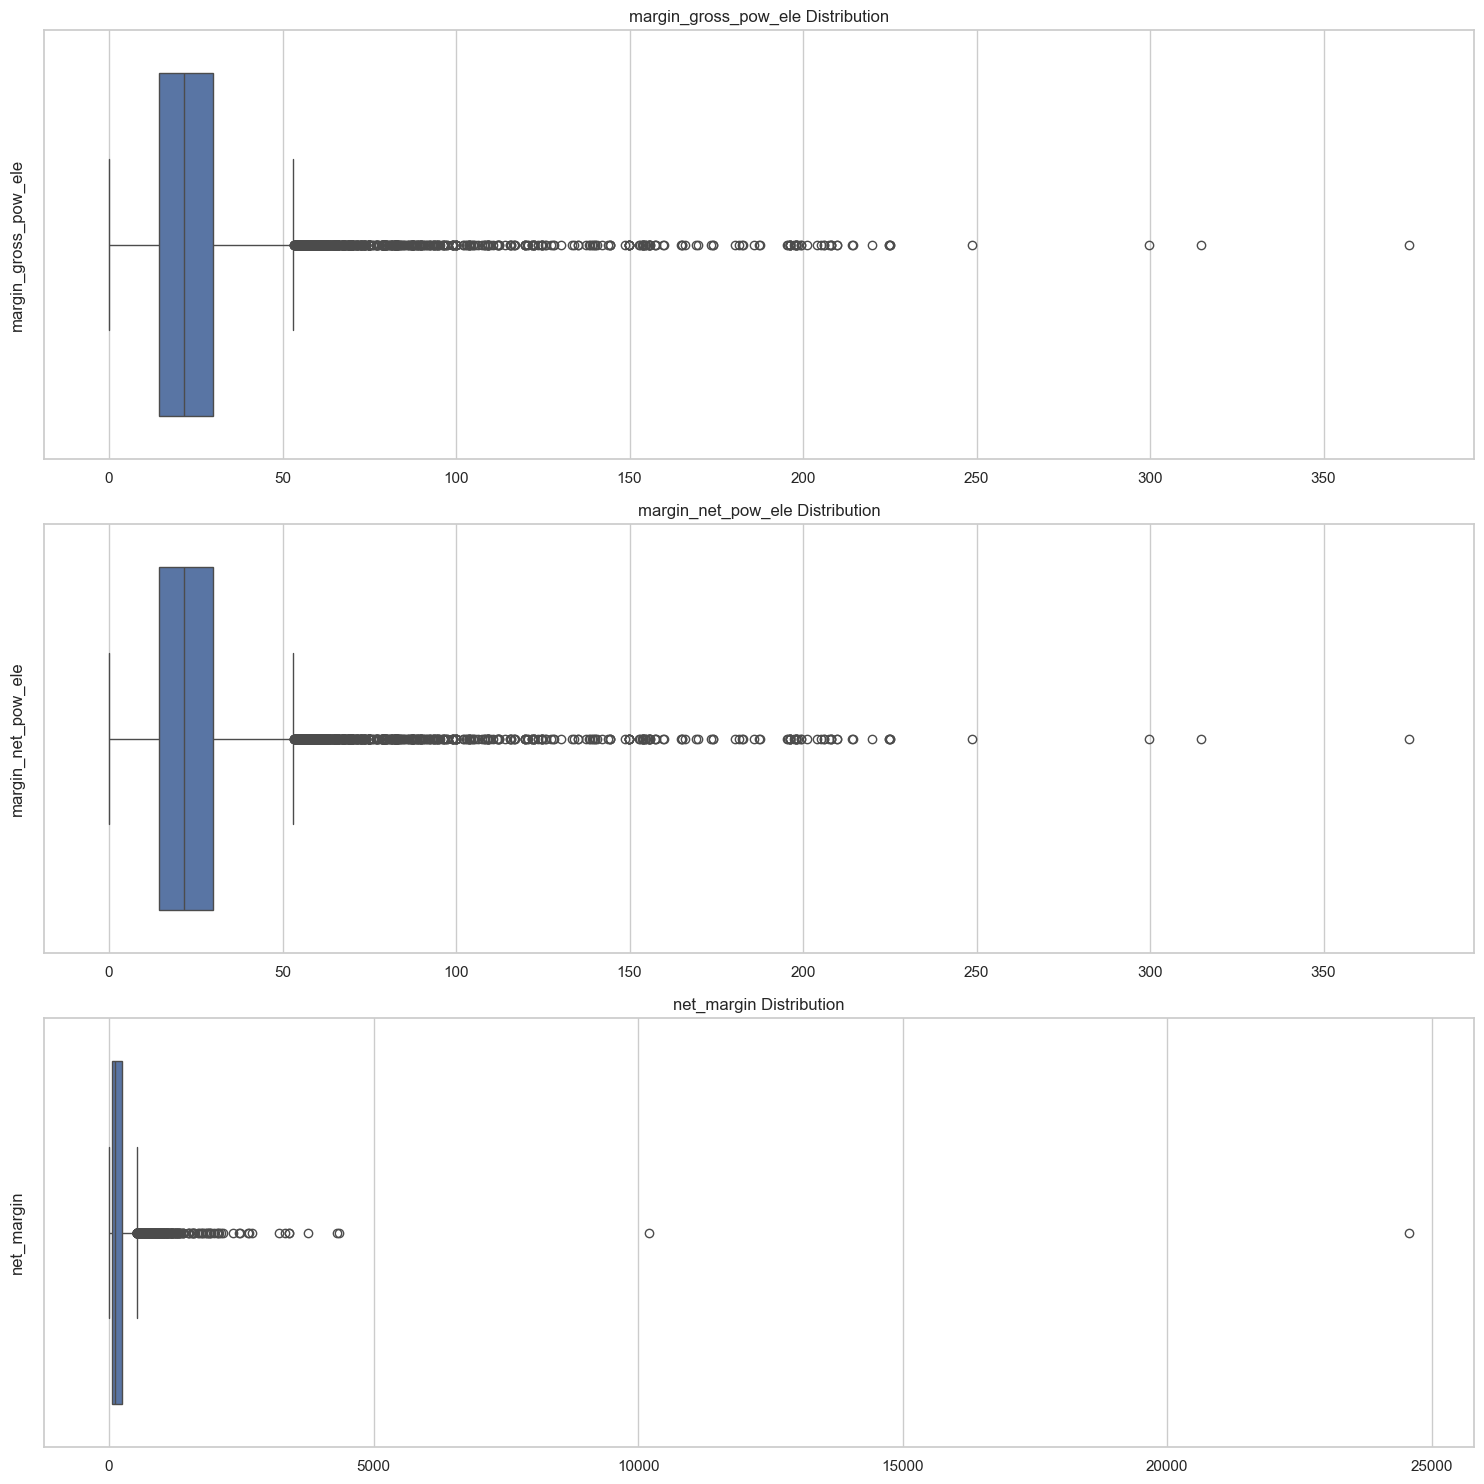

In [17]:
# Execution for margin variables
margin_cols =['margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']
logger.info("Plotting boxplots for margin variables")
plot_boxplot(client_df, margin_cols)

2026-05-01 15:09:51,605 - INFO - Plotting histogram for subscribed power (pow_max)


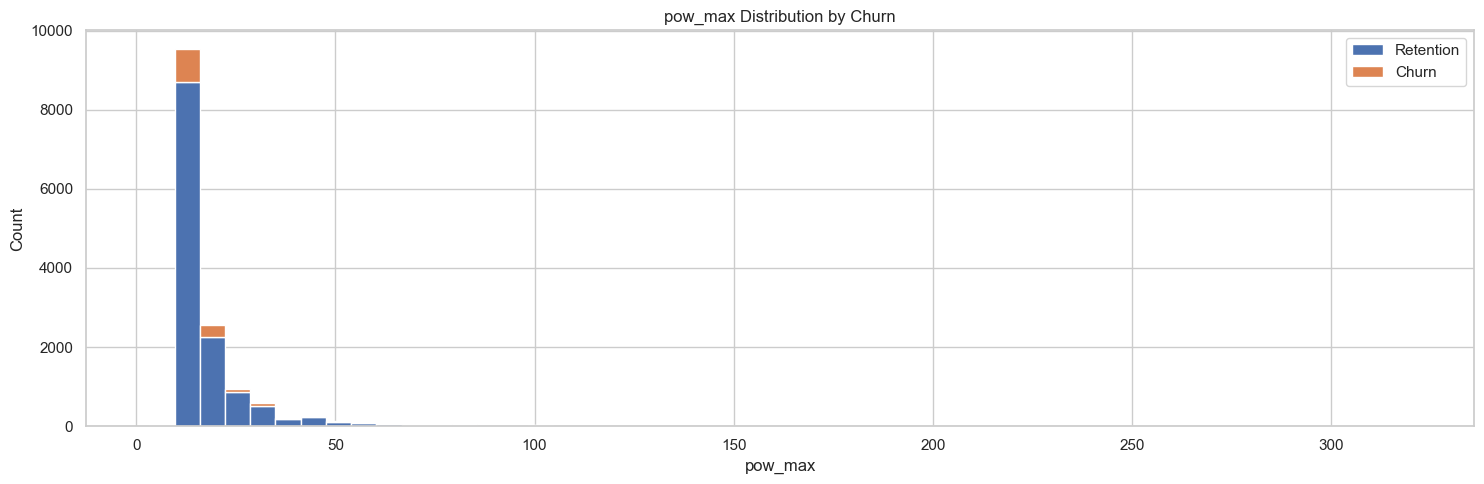

In [18]:
# Execution for maximum subscribed power
logger.info("Plotting histogram for subscribed power (pow_max)")
plot_histograms(client_df, ['pow_max'])

## Executive Summary & Strategic Business Insights

Based on the exploratory data analysis and visualizations, here are the key actionable insights and strategic recommendations to reduce churn and optimize profitability:

### Insight 1: The "Year-2 Cliff" (Antiquity vs. Churn)
* **Observation:** A significant portion of the total churn (27.3%) occurs during the customer's second year (`num_years_antig = 2`).
* **Business Implication:** This suggests that initial "welcome" promotions or first-year aggressive pricing strategies expire, causing customers to experience "bill shock" and switch to competitors once standard rates apply.
* **Actionable Recommendation:** Implement a proactive **"Month-9 Trigger"** program. Instead of offering margin-eating discounts, provide lock-in benefits (e.g., free energy audits, smart meter installations, or priority customer service) 3 months before the first-year contract expires to secure a 12-to-24-month renewal.

### Insight 2: Cross-Selling as a Retention Shield (`has_gas` & `nb_prod_act`)
* **Observation:** Customers subscribed to gas services (`has_gas = 1`) or those holding 5 or more active products (`nb_prod_act >= 5`) exhibit a churn rate of near zero.
* **Business Implication:** Single-product customers have a very low switching cost. Increasing the number of services naturally increases the complexity of switching, tying them closer to our ecosystem.
* **Actionable Recommendation:** Restructure sales channel KPIs. Introduce high-commission incentives for sales representatives who successfully cross-sell gas or additional services to existing single-product electricity customers. 

### Insight 3: The Subscribed Power (`pow_max`) Discrepancy
* **Observation:** Analysis of consumption features versus subscribed power indicates instances where customers subscribe to a high maximum power (`pow_max`) but have relatively low actual consumption (`cons_12m`).
* **Business Implication:** Customers paying for high capacity but utilizing little of it face high fixed monthly fees. This generates a feeling of being overcharged, which is a primary driver for churn.
* **Actionable Recommendation (Win-Win Strategy):** Initiate proactive Customer Success campaigns. Automatically identify customers with severely underutilized `pow_max` and contact them to "optimize their tariff." Lowering their fixed cost builds immense trust and can be exchanged for a new long-term loyalty contract.

### Insight 4: Value-at-Risk (VaR) & Margin Outliers
* **Observation:** The `net_margin` distribution reveals massive outliers, indicating a highly skewed revenue distribution where a small segment of B2B/industrial clients generates the bulk of the profit.
* **Business Implication:** All churn is not created equal from a financial perspective. Losing 1,000 low-margin residential customers is less detrimental than losing 10 high-margin corporate clients.
* **Actionable Recommendation:** The upcoming predictive Machine Learning model should not merely output a churn probability [0 or 1]. The probability metric must be multiplied by the customer's `net_margin` to calculate the **"Expected Financial Loss"**. Retention teams and Call Centers must prioritize their queues strictly based on this Value-at-Risk, focusing retention budgets on the most profitable at-risk accounts.